<a href="https://colab.research.google.com/github/satyamkarn100-ctrl/Cyber-Threat-Detection/blob/main/Email-Phishing-Threat-Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Email Phishing Detection
Six real-world email datasets merged into one pipeline — Enron corporate mail, CEAS spam, Ling mailing list, Nazario phishing, Nigerian fraud, and SpamAssassin. Final model: Logistic Regression (SAGA, C=10) with a 0.3 recall threshold.

| | |
|---|---|
| **Total samples** | ~82,500 emails |
| **Labels** | 0 = Safe, 1 = Phishing/Spam |
| **Final model** | Logistic Regression — 98.55% accuracy |

## 1. Imports

In [ ]:
!pip install wordcloud -q
!pip install -q xgboost
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
import nltk
from nltk.corpus import stopwords
import zipfile
import joblib
import re, time, warnings,os
warnings.filterwarnings('ignore')

In [ ]:
# Kaggle setup
os.environ['KAGGLE_API_TOKEN'] = ''

!pip install -q kaggle

# Download dataset
!kaggle datasets download -d naserabdullahalam/phishing-email-dataset
!kaggle datasets download -d satyamkarn100/email-threat-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset
License(s): CC-BY-SA-4.0
100% 77.1M/77.1M [00:00<00:00, 204MB/s]

Dataset URL: https://www.kaggle.com/datasets/satyamkarn100/email-threat-detection-dataset
License(s): other
100% 34.6M/34.6M [00:00<00:00, 71.6MB/s]



## 2. Data Loading

Dataset is a zip containing 6 separate CSVs. Each source was collected differently — column structure varies across them, so checking each individually before merging.

In [ ]:
with zipfile.ZipFile('email-threat-detection-dataset.zip','r') as zip_ref:
  zip_ref.extractall('email-threat-detection-dataset')

In [ ]:
with zipfile.ZipFile('phishing-email-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

base     = 'dataset'
enron    = pd.read_csv(f'{base}/Enron.csv')
ceas     = pd.read_csv(f'{base}/CEAS_08.csv')
ling     = pd.read_csv(f'{base}/Ling.csv')
nazario  = pd.read_csv(f'{base}/Nazario.csv')
nigerian = pd.read_csv(f'{base}/Nigerian_Fraud.csv')
spamas   = pd.read_csv(f'{base}/SpamAssasin.csv')

## 3. Individual Dataset Inspection

Checking shape, label distribution, missing values, and dtypes for each source before touching anything — good habit before any merge.

### 3.1 Enron
Real corporate emails from Enron (2001). Backbone of the safe class. Energy trading jargon like `ect`, `hou`, `nom` is everywhere — TF-IDF's `max_df` will zero these out automatically.

In [ ]:
print(f'Shape: {enron.shape}')
print(f'Columns: {list(enron.columns)}')
print('\nLabel distribution:')
print(enron['label'].value_counts())
print('\nMissing values:')
print(enron.isnull().sum())
print(f'\nDuplicates: {enron.duplicated().sum()}')

Shape: (29767, 3)
Columns: ['subject', 'body', 'label']

Label distribution:
label
0    15791
1    13976
Name: count, dtype: int64

Missing values:
subject    198
body         0
label        0
dtype: int64

Duplicates: 0


In [ ]:
enron.head()

,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0


In [ ]:
enron.tail(10)

,subject,body,label
29757,only ciiallis help mzcul,""" ci - ialis softabs "" is better than pfizer v...",1
29758,"gain the erection , lose the risk with 100 % n...",rock hard in 20 minutes\r\nmore info here . . ...,1
29759,"get longer , harder , 100 % natural erections !",20 minutes is all it takes\r\nmore info here ....,1
29760,bequest,notification of bequest\r\non behalf of the tr...,1
29761,have you tried these guys out ? impressive,"we offer wholesale repliica bags , watches or ...",1
29762,confidence is back,"hello ,\r\nmy boyfriend began having problems ...",1
29763,important information,love - potion for your darling is all you want...,1
29764,vys - make itnger,you have feelings of guilt and embarrassment ...,1
29765,the best thing come in large parcels,spur - m formula\r\nincrease sperm production ...,1
29766,it works amaziing,"hello , welcome to the medzonlin claiming e\r\...",1


### 3.2 CEAS_08
CEAS 2008 spam challenge dataset. Has extra metadata columns (sender, receiver, date, urls) that we'll drop before merging.

In [ ]:
print(f'Shape: {ceas.shape}')
print(f'Columns: {list(ceas.columns)}')
print('\nLabel distribution:')
print(ceas['label'].value_counts())
print('\nMissing values:')
print(ceas.isnull().sum())
print(f'\nDuplicates: {ceas.duplicated().sum()}')

Shape: (39154, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Label distribution:
label
1    21842
0    17312
Name: count, dtype: int64

Missing values:
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

Duplicates: 0


In [ ]:
ceas.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


### 3.3 Ling
Linguistics mailing list. 100% English, academic tone. All safe emails (label=0). Adds legitimate email variety to balance Enron's corporate style.

In [ ]:
print(f'Shape: {ling.shape}')
print(f'Columns: {list(ling.columns)}')
print('\nLabel distribution:')
print(ling['label'].value_counts())
print('\nMissing values:')
print(ling.isnull().sum())
print(f'\nDuplicates: {ling.duplicated().sum()}')

Shape: (2859, 3)
Columns: ['subject', 'body', 'label']

Label distribution:
label
0    2401
1     458
Name: count, dtype: int64

Missing values:
subject    62
body        0
label       0
dtype: int64

Duplicates: 0


In [ ]:
ling.head()

,subject,body,label
0,job posting - apple-iss research center,content - length : 3386 apple-iss research cen...,0
1,NaN,"lang classification grimes , joseph e . and ba...",0
2,query : letter frequencies for text identifica...,i am posting this inquiry for sergei atamas ( ...,0
3,risk,a colleague and i are researching the differin...,0
4,request book information,earlier this morning i was on the phone with a...,0


### 3.4 Nazario
Hand-collected real phishing emails by security researcher Jose Nazario. All 1565 are phishing (label=1). High quality — actual credential theft attempts.

In [ ]:
print(f'Shape: {nazario.shape}')
print(f'Columns: {list(nazario.columns)}')
print('\nLabel distribution:')
print(nazario['label'].value_counts())
print('\nMissing values:')
print(nazario.isnull().sum())
print(f'\nDuplicates: {nazario.duplicated().sum()}')

Shape: (1565, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

Label distribution:
label
1    1565
Name: count, dtype: int64

Missing values:
sender       0
receiver    96
date         1
subject      4
body         0
urls         0
label        0
dtype: int64

Duplicates: 0


In [ ]:
nazario.head()

,sender,receiver,date,subject,body,urls,label
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1


### 3.5 Nigerian Fraud
Classic 419 advance-fee fraud emails. All phishing (label=1). Written in English — broken/scammy English, but English. Words like `urgent`, `million`, `confidential` are strong phishing signals.

In [ ]:
print(f'Shape: {nigerian.shape}')
print(f'Columns: {list(nigerian.columns)}')
print('\nLabel distribution:')
print(nigerian['label'].value_counts())
print('\nMissing values:')
print(nigerian.isnull().sum())
print(f'\nDuplicates: {nigerian.duplicated().sum()}')

Shape: (3332, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

Label distribution:
label
1    3332
Name: count, dtype: int64

Missing values:
sender       331
receiver    1324
date         482
subject       39
body           0
urls           0
label          0
dtype: int64

Duplicates: 0


In [ ]:
nigerian.head()

,sender,receiver,date,subject,body,urls,label
0,MR. JAMES NGOLA. <james_ngola2002@maktoob.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 02:38:20 +0000",URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,0,1
1,Mr. Ben Suleman <bensul2004nng@spinfinder.com>,R@M,"Thu, 31 Oct 2002 05:10:00 -0000",URGENT ASSISTANCE /RELATIONSHIP (P),"Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",0,1
2,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:17:55 +0100",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0,1
3,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:44:20 -0000",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0,1
4,Maryam Abacha <m_abacha03@www.com>,R@M,"Fri, 01 Nov 2002 01:45:04 +0100",I Need Your Assistance.,"Dear sir, \n \nIt is with a heart full of hope...",0,1


### 3.6 SpamAssassin
Apache SpamAssassin public corpus. Mix of spam and ham. Safe emails here include newsletters — adds diversity to the safe class.

In [ ]:
print(f'Shape: {spamas.shape}')
print(f'Columns: {list(spamas.columns)}')
print('\nLabel distribution:')
print(spamas['label'].value_counts())
print('\nMissing values:')
print(spamas.isnull().sum())
print(f'\nDuplicates: {spamas.duplicated().sum()}')

Shape: (5809, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Label distribution:
label
0    4091
1    1718
Name: count, dtype: int64

Missing values:
sender        0
receiver    210
date          0
subject      16
body          1
label         0
urls          0
dtype: int64

Duplicates: 0


In [ ]:
spamas.head()

,sender,receiver,date,subject,body,label,urls
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,1
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,1


## 4. Merging All Datasets

Steps: fill nulls → drop extra columns → combine subject+body → keep only text+label → concat.

In [ ]:
# fill null subjects and bodies before combining
for df in [enron, ceas, ling, nazario, nigerian, spamas]:
    df['subject'] = df['subject'].fillna('')
spamas['body'] = spamas['body'].fillna('')

In [ ]:
# verify no nulls remain in columns we care about
for name, df in [('enron',enron),('ceas',ceas),('ling',ling),
                  ('nazario',nazario),('nigerian',nigerian),('spamas',spamas)]:
    nulls = df[['subject','body','label']].isnull().sum().sum()
    print(f'{name}: {nulls} nulls remaining')

enron: 0 nulls remaining
ceas: 0 nulls remaining
ling: 0 nulls remaining
nazario: 0 nulls remaining
nigerian: 0 nulls remaining
spamas: 0 nulls remaining


In [ ]:
# drop metadata columns — only some datasets have them
for df in [ceas, nazario, nigerian, spamas]:
    df.drop(columns=['sender','receiver','date','urls'], inplace=True, errors='ignore')

In [ ]:
# quick check — all should now have same 3 columns
for name, df in [('enron',enron),('ceas',ceas),('ling',ling),
                  ('nazario',nazario),('nigerian',nigerian),('spamas',spamas)]:
    print(f'{name}: {list(df.columns)}')

enron: ['subject', 'body', 'label']
ceas: ['subject', 'body', 'label']
ling: ['subject', 'body', 'label']
nazario: ['subject', 'body', 'label']
nigerian: ['subject', 'body', 'label']
spamas: ['subject', 'body', 'label']


In [ ]:
# subject + body → single text field
for df in [enron, ceas, ling, nazario, nigerian, spamas]:
    df['text'] = df['subject'] + ' ' + df['body']

enron    = enron[['text','label']]
ceas     = ceas[['text','label']]
ling     = ling[['text','label']]
nazario  = nazario[['text','label']]
nigerian = nigerian[['text','label']]
spamas   = spamas[['text','label']]

In [ ]:
# merge all 6, reset index
email_df = pd.concat(
    [enron, ceas, ling, nazario, nigerian, spamas],
    ignore_index=True
)

print(f'Total rows: {email_df.shape[0]}')
print(f'\nLabel distribution:')
print(email_df['label'].value_counts())
print(f'\nClass balance:')
print(email_df['label'].value_counts(normalize=True).round(3))

Total rows: 82486

Label distribution:
label
1    42891
0    39595
Name: count, dtype: int64

Class balance:
label
1    0.52
0    0.48
Name: proportion, dtype: float64


In [ ]:
# Load the manually collected email threat detection dataset
manual_df = pd.read_csv("email-threat-detection-dataset/email_threat_detection.csv")

In [ ]:
final_df = pd.concat([email_df,manual_df],ignore_index=True)
print(f'Shape: {final_df.shape}')
print(f'Columns: {list(final_df.columns)}')
print('\nLabel distribution:')
print(final_df['label'].value_counts())
print('\nMissing values:')
print(spamas.isnull().sum())
print(f'\nDuplicates: {final_df.duplicated().sum()}')


Shape: (186004, 2)
Columns: ['text', 'label']

Label distribution:
label
0    97506
1    88498
Name: count, dtype: int64

Missing values:
text     0
label    0
dtype: int64

Duplicates: 0


In [ ]:
final_df.tail()

,text,label
185999,Dear customer.Tired of paying twice the price ...,1
186000,We represent for you\ninternet shop of digital...,1
186001,/\\\nLet employers find you on job banks & job...,0
186002,"On [DATE], [NAME] <|EMAIL|> wrote:\nHi,\nI hav...",0
186003,We represent for you\ninternet shop of digital...,1


## 5. Exploratory Data Analysis

EDA is split into two parts:
- **Before cleaning** — class balance and word count (these don't need clean text)
- **After cleaning** — top words and wordcloud (these need clean text to be meaningful)

Doing word-level visualizations on raw text would just show stopwords like `that`, `this`, `with` — which tells us nothing. So those plots come after the cleaning step.

### 5.1 Class Distribution
58% safe vs 42% phishing — reasonably balanced. No SMOTE or oversampling needed.

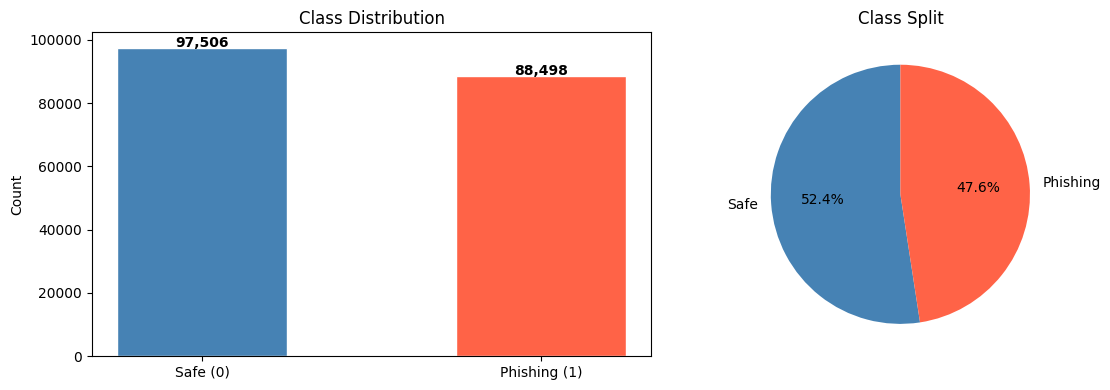

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
counts = final_df['label'].value_counts()
axes[0].bar(['Safe (0)', 'Phishing (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

# pie chart
axes[1].pie(counts.values, labels=['Safe', 'Phishing'],
            colors=['steelblue','tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Split')

plt.tight_layout()
plt.show()

### 5.2 Word Count Distribution
Phishing emails tend to be shorter and punchier — urgency is the tactic. Safe emails (especially Enron) are longer professional threads.

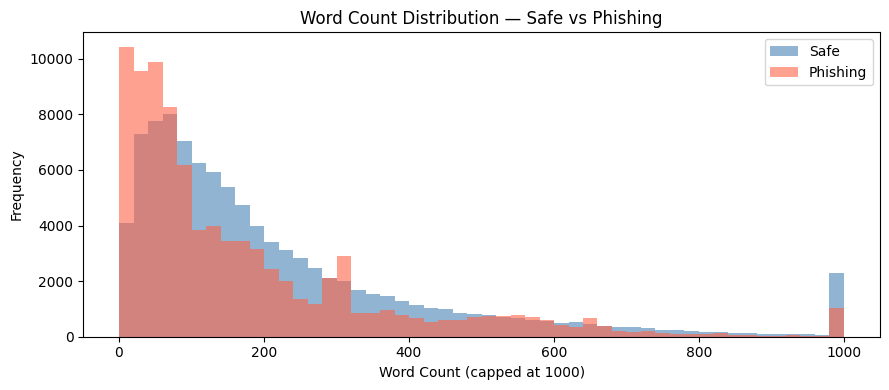

         count   mean    std  min   25%    50%    75%       max
label                                                          
0      97505.0  252.5  570.2  1.0  73.0  149.0  288.0   45450.0
1      88498.0  188.8  532.6  1.0  45.0  100.0  239.0  127127.0


In [ ]:
final_df['word_count'] = final_df['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0,'steelblue','Safe'), (1,'tomato','Phishing')]:
    data = final_df[final_df['label']==label]['word_count'].clip(upper=1000)
    ax.hist(data, bins=50, alpha=0.6, color=color, label=name)
ax.set_xlabel('Word Count (capped at 1000)')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Distribution — Safe vs Phishing')
ax.legend()
plt.tight_layout()
plt.show()

print(final_df.groupby('label')['word_count'].describe().round(1))

## 6. Text Cleaning

Cleaning order matters. Each step removes a different type of noise:

| Step | Removes |
|------|---------|
| Lowercase | case inconsistency |
| URL removal | `http://...` links |
| Email removal | `user@domain.com` addresses |
| Digit removal | phone numbers, dates, prices |
| Special chars | punctuation, symbols |
| Stopwords | `the`, `is`, `at`, `with`... |
| Length filter `> 2` | single/double char noise |
| Vowel filter | garbled base64 debris like `zjj`, `kmt`, `dcz` |

The vowel filter is the non-obvious one — encoding artifacts have no vowels, so one `re.search(r'[aeiou]', t)` check wipes all of them.

In [ ]:
# step 1-5: regex-based cleaning
final_df['text'] = final_df['text'].str.lower()
final_df['text'] = final_df['text'].str.replace(r'https?://\S+|www\.\S+', ' ', regex=True)
final_df['text'] = final_df['text'].str.replace(r'\S+@\S+', ' ', regex=True)
final_df['text'] = final_df['text'].str.replace(r'\d', ' ', regex=True)
final_df['text'] = final_df['text'].str.replace(r'[^a-z\s]', ' ', regex=True)
final_df['text'] = final_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

print('Regex cleaning done.')
print('Sample after step 1-5:')
print(final_df['text'].iloc[1][:200])

Regex cleaning done.
Sample after step 1-5:
re nom actual vols for th forwarded by sabrae zajac hou ect on pm enron capital trade resources corp from eileen ponton am to davilal txu com cstonel txu com mjones txu com hpl scheduling enron com li


In [ ]:
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))  # english only — dataset is english-dominant

def final_clean(text):
    if not isinstance(text, str):
        return ''
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]       # english stopwords out
    tokens = [t for t in tokens if len(t) > 2]                # short noise out
    tokens = [t for t in tokens if re.search(r'[aeiou]', t)] # vowel filter — kills base64 garbage
    return ' '.join(tokens)

final_df['text'] = final_df['text'].apply(final_clean)

# drop rows that becafinal_df after cleaning
before = len(final_df)
final_df = final_df[final_df['text'].str.strip() != ''].reset_index(drop=True)
print(f'Dropped {before - len(final_df)} empty rows')
print(f'Final shape: {final_df.shape}')
print('\nSample after full cleaning:')
print(final_df['text'].iloc[1][:200])

Dropped 141 empty rows
Final shape: (185863, 3)

Sample after full cleaning:
nom actual vols forwarded sabrae zajac hou ect enron capital trade resources corp eileen ponton davilal txu com cstonel txu com mjones txu com scheduling enron com liz bellamy enron com szajac enron c


## 7. EDA — Word Analysis (Post-Cleaning)

Now that stopwords and noise are gone, top words and wordclouds actually tell us something. These are the features TF-IDF will be working with.

### 7.1 Top 20 Words Per Class
Stopwords removed, length > 2, vowel filter applied — these are genuinely discriminative words.

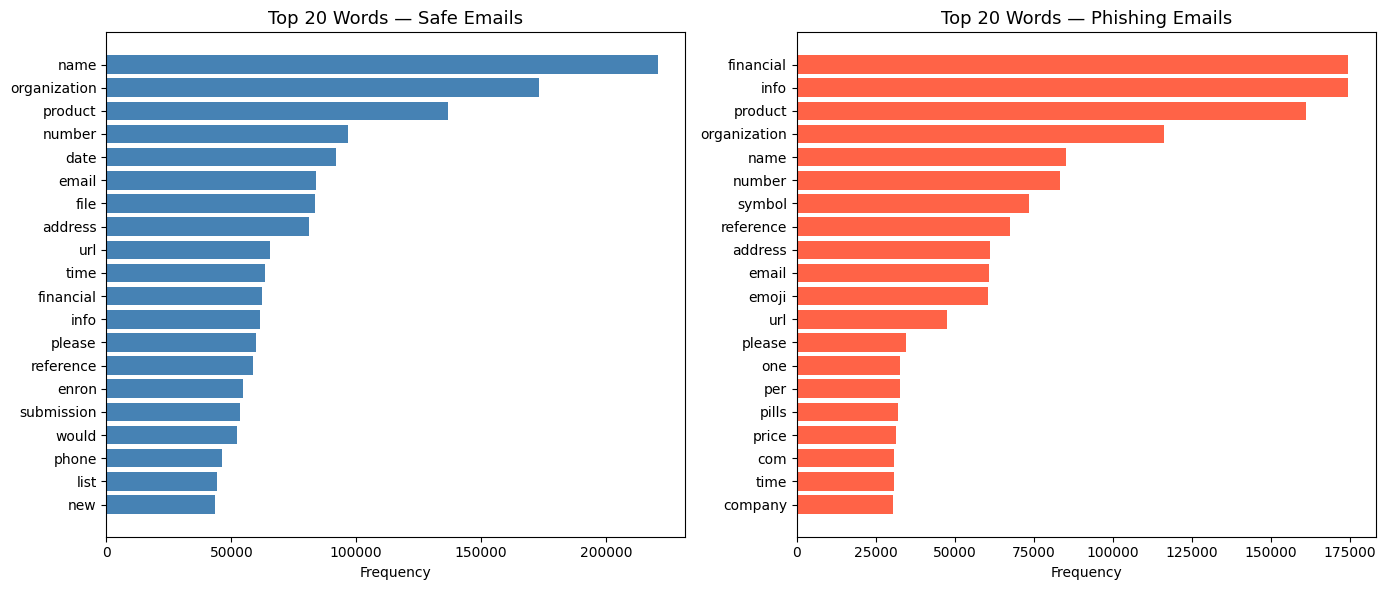

In [ ]:
# top words AFTER cleaning — stopwords already gone from text
def get_top_words(series, n=20):
    text = ' '.join(series.dropna())
    return Counter(text.split()).most_common(n)

safe_words  = get_top_words(final_df[final_df['label']==0]['text'])
phish_words = get_top_words(final_df[final_df['label']==1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_s, counts_s = zip(*safe_words)
axes[0].barh(words_s[::-1], counts_s[::-1], color='steelblue')
axes[0].set_title('Top 20 Words — Safe Emails', fontsize=13)
axes[0].set_xlabel('Frequency')

words_p, counts_p = zip(*phish_words)
axes[1].barh(words_p[::-1], counts_p[::-1], color='tomato')
axes[1].set_title('Top 20 Words — Phishing Emails', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### 7.2 WordCloud
Visual summary — bigger word = more frequent in that class.

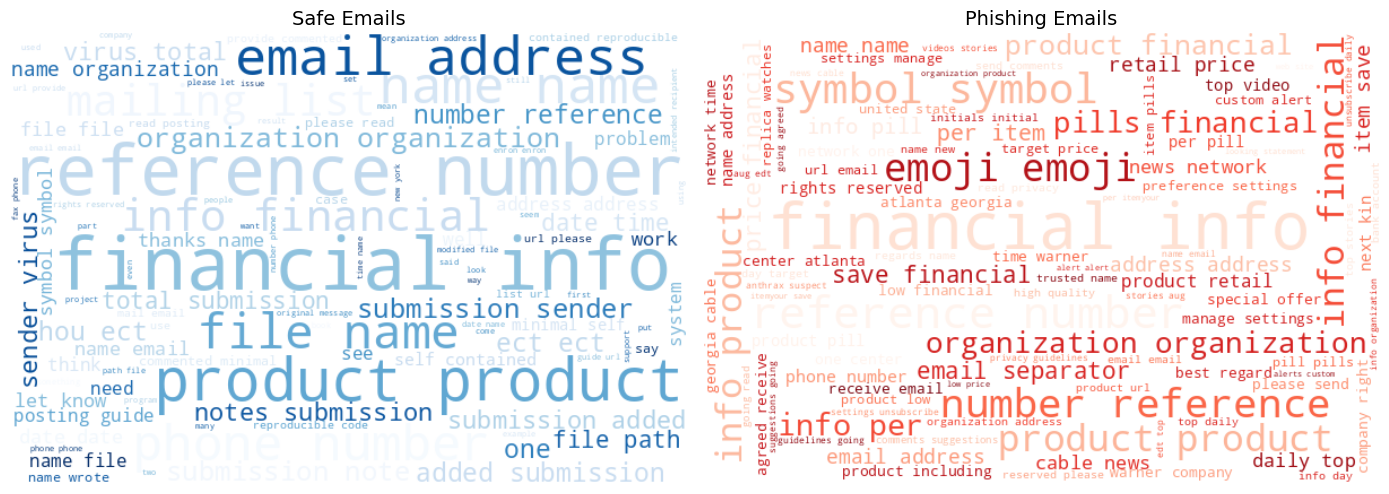

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, cmap, title in [
    (axes[0], 0, 'Blues',  'Safe Emails'),
    (axes[1], 1, 'Reds',   'Phishing Emails')
]:
    text = ' '.join(final_df[final_df['label']==label]['text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()

## 8. Feature Engineering — TF-IDF

**Why TF-IDF parameters matter here:**

- `max_df=0.85` — words in >85% of docs get near-zero weight. This handles Enron-specific words like `enron`, `ect`, `hou` that would cause shortcut learning.
- `min_df=5` — words appearing in fewer than 5 emails are likely noise or typos.
- `ngram_range=(1,2)` — bigrams like `verify account`, `click here`, `free offer` are stronger signals than single words alone.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    max_df=0.85,       # kills domain-specific noise automatically
    min_df=5,          # ignores very rare tokens
    ngram_range=(1,2)  # unigrams + bigrams
)

X = tfidf.fit_transform(final_df['text'])
y = final_df['label']

# stratify keeps class ratio same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'TF-IDF matrix: {X.shape}')
print(f'Train size:    {X_train.shape[0]:,}')
print(f'Test size:     {X_test.shape[0]:,}')

TF-IDF matrix: (185863, 5000)
Train size:    148,690
Test size:     37,173


## 9. Model Training

Four models trained and compared. Custom threshold **0.3** used instead of default 0.5 — in phishing detection, a missed phishing email (false negative) is more dangerous than a false alarm (false positive). Lowering threshold increases recall at cost of some precision. That's the right trade-off here.

### 9.1 Naive Bayes — Baseline
First model to try on text data. Fast, simple, often surprisingly good. Sets the baseline that other models have to beat.

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_nb))
print('\nClassification Report (threshold=0.5):')
print(classification_report(y_test, y_pred_nb))

Confusion Matrix:
[[18663   835]
 [ 2047 15628]]

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     19498
           1       0.95      0.88      0.92     17675

    accuracy                           0.92     37173
   macro avg       0.93      0.92      0.92     37173
weighted avg       0.92      0.92      0.92     37173



In [ ]:
# lower threshold: recall goes up, some safe emails flagged as phishing — acceptable trade-off
nb_probs = nb_model.predict_proba(X_test)[:, 1]
nb_thresh_preds = (nb_probs >= 0.3).astype(int)

print('Confusion Matrix (threshold=0.3):')
print(confusion_matrix(y_test, nb_thresh_preds))
print('\nClassification Report (threshold=0.3):')
print(classification_report(y_test, nb_thresh_preds))

Confusion Matrix (threshold=0.3):
[[17934  1564]
 [  852 16823]]

Classification Report (threshold=0.3):
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     19498
           1       0.91      0.95      0.93     17675

    accuracy                           0.94     37173
   macro avg       0.93      0.94      0.93     37173
weighted avg       0.94      0.94      0.94     37173



### 9.2 Logistic Regression — Final Model

**Why SAGA solver?** Faster convergence on large sparse matrices like TF-IDF output.

**Why C=10?** Less regularization — our features are already filtered by `max_df`/`min_df`, so we don't need aggressive shrinkage.

**Why threshold=0.3?** Maximizes phishing recall. A missed phishing email = compromised account. A false alarm = one unnecessary warning. Former is far worse.

This is the deployment model: ~30s training, ~2MB pkl file, fast inference.

In [ ]:
# saga solver — best choice for large sparse TF-IDF matrices
log_model = LogisticRegression(solver='saga', C=10, max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

print(f'Training Accuracy: {log_model.score(X_train, y_train):.4f}')
print(f'Testing Accuracy:  {log_model.score(X_test, y_test):.4f}')

Training Accuracy: 0.9743
Testing Accuracy:  0.9656


In [ ]:
print('Classification Report (threshold=0.5 — default):')
y_pred_lr = log_model.predict(X_test)
print(classification_report(y_test, y_pred_lr))

Classification Report (threshold=0.5 — default):
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     19498
           1       0.96      0.97      0.96     17675

    accuracy                           0.97     37173
   macro avg       0.97      0.97      0.97     37173
weighted avg       0.97      0.97      0.97     37173



In [ ]:
# threshold 0.3 — phishing recall priority
lr_probs = log_model.predict_proba(X_test)[:, 1]
lr_thresh_preds = (lr_probs >= 0.3).astype(int)

print('Classification Report (threshold=0.3 — recall optimized):')
print(classification_report(y_test, lr_thresh_preds))

print('Confusion Matrix (threshold=0.3):')
print(confusion_matrix(y_test, lr_thresh_preds))

Classification Report (threshold=0.3 — recall optimized):
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     19498
           1       0.94      0.98      0.96     17675

    accuracy                           0.96     37173
   macro avg       0.96      0.96      0.96     37173
weighted avg       0.96      0.96      0.96     37173

Confusion Matrix (threshold=0.3):
[[18369  1129]
 [  338 17337]]


In [ ]:
# this is the final deployment model
final_model = log_model
final_threshold = 0.3

### 9.3 XGBoost
Good performer. Used GPU on Colab to speed up training. Params set based on what typically works for high-dimensional sparse text features.

In [ ]:
XGB_Model = XGBClassifier(
    random_state=42,
    device='cuda',     # colab GPU
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1
)
XGB_Model.fit(X_train, y_train)
y_pred_xgb = XGB_Model.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix:
[[18420  1078]
 [  633 17042]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     19498
           1       0.94      0.96      0.95     17675

    accuracy                           0.95     37173
   macro avg       0.95      0.95      0.95     37173
weighted avg       0.95      0.95      0.95     37173



In [ ]:
from sklearn.model_selection import GridSearchCV

XGB_model = XGBClassifier(
    random_state=42,
    device='cuda',
    eval_metric='logloss'
)

XGB_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1]
}

print('Running XGBoost GridSearch...')
start = time.time()

grid_search_xgb = GridSearchCV(
    estimator=XGB_model,
    param_grid=XGB_params,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)

print(f'\nDone in {(time.time()-start)/60:.2f} minutes')
print('Best params:', grid_search_xgb.best_params_)

y_pred_xgb = grid_search_xgb.predict(X_test)

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Running XGBoost GridSearch...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   6.9s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   5.9s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   6.8s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=200; total time=   9.7s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=200; total time=   9.5s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=200; total time=  10.8s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   9.4s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   9.5s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   9.8s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=200; total time=  16.5s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=200; total time=  15.2s
[CV] END ..learning

### 9.4 Random Forest — Tuned
RandomizedSearchCV instead of GridSearch — trying all combinations on 82k rows would take hours. 5 random candidates with 3-fold CV gives good enough best params. Result: 98% F1 but 26 minutes training — that's why LR was chosen for deployment.

In [ ]:
# Best params: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}
RF_model = RandomForestClassifier(random_state=42, n_jobs=1)
RF_params = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

print('Running RandomizedSearchCV...')
start = time.time()

random_Search = RandomizedSearchCV(
    estimator=RF_model,
    param_distributions=RF_params,
    n_iter=5, cv=3, scoring='f1',
    random_state=42, n_jobs=-1, verbose=2
)
random_Search.fit(X_train, y_train)

print(f'\nDone in {(time.time()-start)/60:.2f} minutes')
print(f'Best params: {random_Search.best_params_}')
y_pred_rf = random_Search.predict(X_test)
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Running RandomizedSearchCV...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Done in 56.42 minutes
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}

Confusion Matrix:
[[19071   427]
 [  555 17120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     19498
           1       0.98      0.97      0.97     17675

    accuracy                           0.97     37173
   macro avg       0.97      0.97      0.97     37173
weighted avg       0.97      0.97      0.97     37173



In [ ]:
# rf threshold 0.3 — almost no false negatives (16 phishing missed out of 8537)
rf_probs = random_Search.predict_proba(X_test)[:, 1]
rf_thresh_preds = (rf_probs >= 0.3).astype(int)

print('Confusion Matrix (threshold=0.3):')
print(confusion_matrix(y_test, rf_thresh_preds))

## 10. Model Comparison

All models perform well. Decision comes down to practical factors for deployment.

In [ ]:
comparison = pd.DataFrame({
    'Model':        ['Naive Bayes', 'Logistic Regression', 'XGBoost', 'Random Forest'],
    'Accuracy':     [0.97,           0.9855,                0.98,       0.98],
    'F1 (default)': [0.97,           0.985,                 0.98,       0.98],
    'Train Time':   ['< 1s',         '~30s',                '~5min',    '26 min'],
    'pkl Size':     ['small',        'small',               'medium',   'large'],
    'Deployment':   ['OK',           'Best ✓',              'OK',       'Heavy']
})

print(comparison.to_string(index=False))

## 11. Save Final Model

In [49]:
# Save trained RF model and fitted TF-IDF vectorizer
joblib.dump(random_Search, 'email_rf_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print('Saved:')
print('  email_rf_model.pkl      — RF RandomizedSearchCV model')
print('  tfidf_vectorizer.pkl    — fitted TF-IDF vectorizer')

Saved:
  email_rf_model.pkl      — RF RandomizedSearchCV model
  tfidf_vectorizer.pkl    — fitted TF-IDF vectorizer


In [48]:
test_emails = [
    "how are you?",
    "can you call me?",
    "what are you doing?",
    "okay thanks",
    "see you tomorrow",
    "please send me the notes"
]

for text in test_emails:
    X = tfidf.transform([text])
    proba = log_model.predict_proba(X)[0][1]
    print(f"{text:30} -> {proba:.4f}")

how are you?                   -> 0.8168
can you call me?               -> 0.1684
what are you doing?            -> 0.8168
okay thanks                    -> 0.0037
see you tomorrow               -> 0.0440
please send me the notes       -> 0.5658


In [ ]:
text = "how are you?"

X = tfidf.transform([text])
feature_names = tfidf.get_feature_names_out()
coefs = log_model.coef_[0]

print("Logit:", log_model.decision_function(X)[0])
print("Probability:", log_model.predict_proba(X)[0][1])

indices = X.nonzero()[1]

print("\nActive features:", len(indices))

for idx in indices[:20]:
    feature = feature_names[idx]
    value = X[0, idx]
    coef = coefs[idx]
    contribution = value * coef

    print(feature, value, coef, contribution)

Logit: 1.4945664737005324
Probability: 0.8167626862375016

Active features: 0
